# Assignment: Unsupervised Learning on Iris Dataset

## Objectives
1. **K-Means Clustering** — Perform K-Means clustering and determine the optimal number of clusters using the elbow method.
2. **DBSCAN Clustering** — Apply DBSCAN and experiment with `eps` and `min_samples` to find meaningful clusters.

## Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
feature_names = iris.feature_names
target_names = iris.target_names

# Standardize features for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview the data
df = pd.DataFrame(X, columns=feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


---

## Part 1: K-Means Clustering

### Step 2: Elbow Method — Finding the Optimal K

We run K-Means for K = 1 to 10 and plot the **inertia** (within-cluster sum of squares). The "elbow" in the curve suggests the optimal number of clusters.

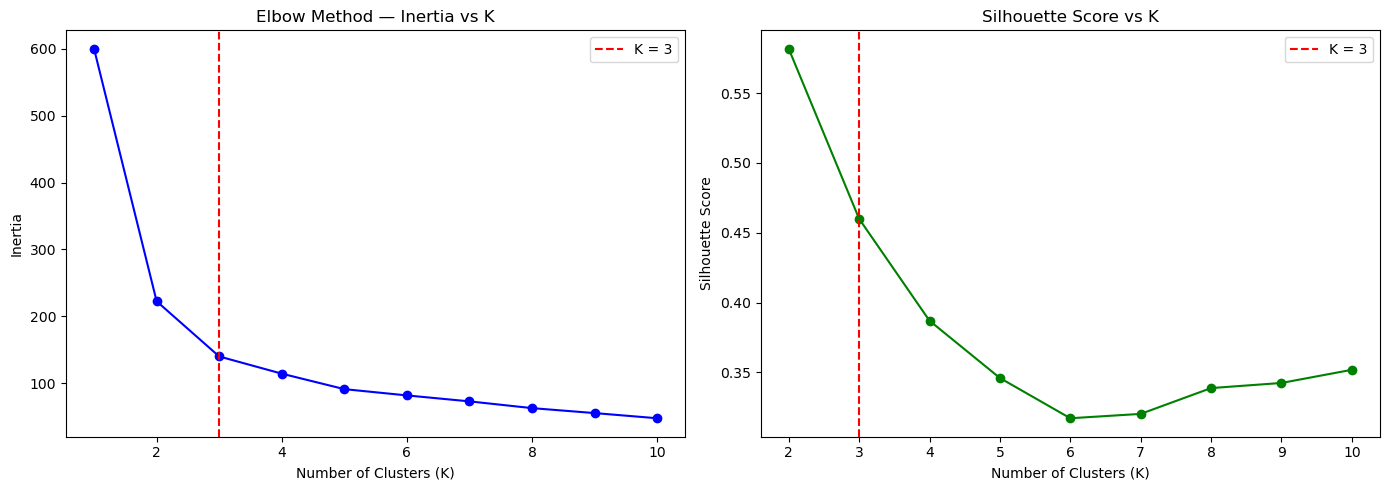

Silhouette scores: {2: 0.5818, 3: 0.4599, 4: 0.3869, 5: 0.3459, 6: 0.3171, 7: 0.3202, 8: 0.3387, 9: 0.3424, 10: 0.3518}


In [ ]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

# Compute inertia for K = 1..10, silhouette for K = 2..10
# silhouette_score is defined as (b - a) / max(a, b) where:
# a = average intra-cluster distance (mean distance to other points in the same cluster)
# b = average nearest-cluster distance (mean distance to points in the nearest cluster). 
# It measures how similar an object is to its own cluster compared to other clusters. 
# The score ranges from -1 to 1, where a higher score indicates better-defined clusters.
# K = 1 is not valid for silhouette_score since it requires at least 2 clusters to compute the score.

for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method — Inertia vs K")
axes[0].axvline(x=3, color="r", linestyle="--", label="K = 3")
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores, "go-")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].axvline(x=3, color="r", linestyle="--", label="K = 3")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Silhouette scores: { {k: round(s, 4) for k, s in zip(K_range, silhouette_scores)} }")

### Interpretation of the Plots

**Left Plot — Elbow Method (Inertia vs K):**
Inertia measures the total within-cluster sum of squared distances from each point to its cluster centroid. As K increases, inertia always decreases (more clusters = tighter groups). The goal is to find the **"elbow"** — the point where adding more clusters yields diminishing returns. Here, inertia drops sharply from K=1 to K=3, then flattens out. The red dashed line at **K=3** marks this elbow, suggesting 3 is the optimal number of clusters.

**Right Plot — Silhouette Score vs K:**
The silhouette score measures how well each point fits within its assigned cluster compared to the nearest neighboring cluster. Scores range from -1 (wrong cluster) to 1 (well-clustered). A higher score indicates better-defined, well-separated clusters. In this plot, the silhouette score is highest at K=2, but drops at K=3 and continues declining. Despite K=2 having a higher silhouette score, **K=3 is chosen** because:
1. The elbow method clearly points to K=3.
2. We know the Iris dataset has 3 true species, and domain knowledge supports this choice.
3. The silhouette score at K=3 (~0.46) is still reasonable, indicating meaningful cluster structure.

**Takeaway:** The two methods complement each other — the elbow method identifies where inertia gains diminish, while the silhouette score evaluates cluster quality. Together, they support **K=3** as the optimal choice for this dataset.

### Step 3: Apply K-Means with Optimal K

Based on the elbow method, **K = 3** is the optimal number of clusters (matching the 3 Iris species).

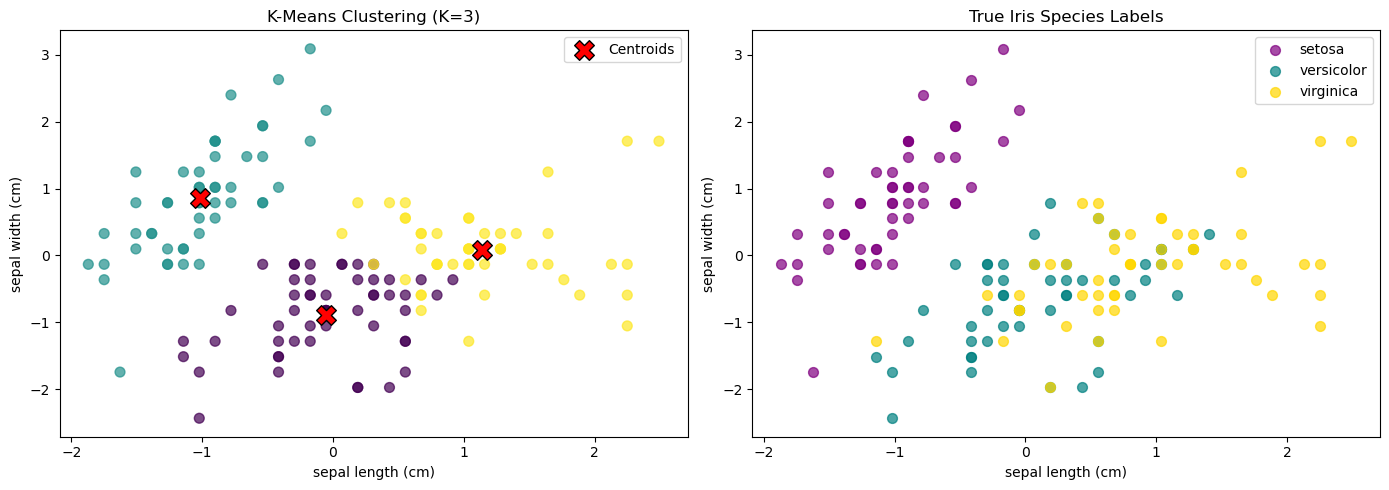

K-Means Silhouette Score (K=3): 0.4599


In [4]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Visualize clusters using first two features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means result
scatter1 = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap="viridis", s=50, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c="red", marker="X", s=200, edgecolors="black", label="Centroids")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title(f"K-Means Clustering (K={optimal_k})")
axes[0].legend()

# True labels for comparison — plot each species separately for legend
colors = ["purple", "teal", "gold"]
for i, name in enumerate(target_names):
    mask = iris.target == i
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1], c=colors[i], s=50, alpha=0.7, label=name)
axes[1].set_xlabel(feature_names[0])
axes[1].set_ylabel(feature_names[1])
axes[1].set_title("True Iris Species Labels")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"K-Means Silhouette Score (K={optimal_k}): {silhouette_score(X_scaled, kmeans_labels):.4f}")

### Interpretation of K-Means vs True Labels

**Left Plot — K-Means Clustering (K=3):**
Each data point is colored by its K-Means assigned cluster. The three large **red "X" markers** are the **centroids** — the mean position of all points in each cluster. K-Means iteratively repositions these centroids until convergence, assigning each point to its nearest centroid. The centroids represent the "center of mass" of each cluster in feature space. Here we plot only the first two features (sepal length and sepal width), so the centroids reflect the average sepal length and sepal width of the points in their respective clusters.

**Right Plot — True Iris Species Labels:**
The same data points are shown, but colored by their actual species (setosa, versicolor, virginica). There are no centroids here since these are ground-truth labels, not a clustering result.

**Comparing the two plots:**
The K-Means clusters align reasonably well with the true species groupings. One species (setosa, the upper-left cluster) is cleanly separated, while the other two (versicolor and virginica) overlap in the sepal length/width space, making them harder to distinguish — both for K-Means and visually. This overlap explains why the silhouette score is moderate (~0.46) rather than close to 1.

---

## Part 2: DBSCAN Clustering

### Step 4: Experiment with `eps` and `min_samples`

DBSCAN does not require specifying the number of clusters upfront. Instead, we tune `eps` (neighborhood radius) and `min_samples` (minimum points to form a dense region). Points not belonging to any cluster are labeled as **noise (-1)**.

In [ ]:
eps_values = [0.3, 0.5, 0.7, 0.9] 
# eps (epsilon) is the maximum distance between two samples 
# for them to be considered as in the same neighborhood. Numbers are selected based on typical values for standardized data.
min_samples_values = [3, 5, 7, 10] 
# min_samples is the number of samples in a neighborhood 
# for a point to be considered as a core point. Numbers are selected based on common defaults and to explore a range of values for the Iris dataset which has 150 samples.

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        sil = silhouette_score(X_scaled, labels) if n_clusters >= 2 else -1
        results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": round(sil, 4)
        })

results_df = pd.DataFrame(results)
results_df

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.3,3,10,84,-0.1473
1,0.3,5,3,120,-0.1942
2,0.3,7,2,129,0.1751
3,0.3,10,0,150,-1.0000
4,0.5,3,7,17,0.1597
5,0.5,5,2,34,0.3565
6,0.5,7,5,46,0.1391
7,0.5,10,3,89,0.0094
8,0.7,3,2,5,0.5081
9,0.7,5,2,6,0.5234


### Step 5: Visualize Best DBSCAN Configuration

Select the configuration with the best silhouette score and visualize the resulting clusters.

Best DBSCAN config: eps=0.7, min_samples=5
  Clusters: 2, Noise points: 6, Silhouette: 0.5234


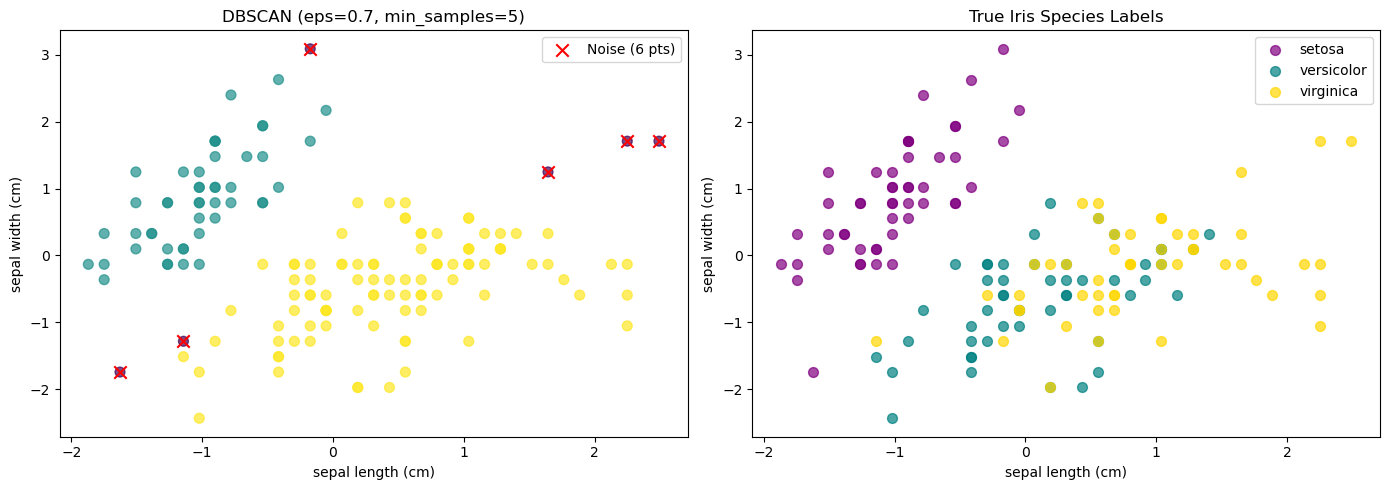

In [7]:
# Pick the best configuration by silhouette score
best = results_df.loc[results_df["silhouette"].idxmax()]
print(f"Best DBSCAN config: eps={best['eps']}, min_samples={int(best['min_samples'])}")
print(f"  Clusters: {int(best['n_clusters'])}, Noise points: {int(best['n_noise'])}, Silhouette: {best['silhouette']}")

# Run DBSCAN with best parameters
dbscan_best = DBSCAN(eps=best["eps"], min_samples=int(best["min_samples"]))
dbscan_labels = dbscan_best.fit_predict(X_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DBSCAN result
scatter1 = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap="viridis", s=50, alpha=0.7)
noise_mask = dbscan_labels == -1
axes[0].scatter(X_scaled[noise_mask, 0], X_scaled[noise_mask, 1],
                c="red", marker="x", s=80, label=f"Noise ({noise_mask.sum()} pts)")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].set_title(f"DBSCAN (eps={best['eps']}, min_samples={int(best['min_samples'])})")
axes[0].legend()

# True labels for comparison — plot each species separately for legend
colors = ["purple", "teal", "gold"]
for i, name in enumerate(target_names):
    mask = iris.target == i
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1], c=colors[i], s=50, alpha=0.7, label=name)
axes[1].set_xlabel(feature_names[0])
axes[1].set_ylabel(feature_names[1])
axes[1].set_title("True Iris Species Labels")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation of DBSCAN vs True Labels

**Left Plot — DBSCAN Clustering (eps=0.7, min_samples=5):**
DBSCAN found **2 clusters** and identified **6 noise points** (marked with red "x"). Unlike K-Means, DBSCAN does not require specifying the number of clusters — it discovers them based on density. Points that don't have enough neighbors within `eps` distance are labeled as noise. The two clusters correspond to: (1) setosa, which is well-separated, and (2) versicolor + virginica merged into a single cluster, since they are too close together in feature space for DBSCAN to split them apart at this `eps` radius.

**Right Plot — True Iris Species Labels:**
The same data colored by actual species (setosa, versicolor, virginica), showing the 3-class ground truth for comparison.

**Are these meaningful clusters?**

Yes — the clusters found by DBSCAN are meaningful, but with a key limitation. The selected parameters (`eps=0.7`, `min_samples=5`) achieved the **highest silhouette score (0.5234)** across all 16 tested configurations, which is actually higher than K-Means' score of ~0.46. However, DBSCAN only found **2 clusters instead of 3**, merging versicolor and virginica into one group. This is because these two species overlap significantly in feature space and do not have a clear density gap between them.

The parameter values tested (`eps`: 0.3–0.9, `min_samples`: 3–10) were not random — they were chosen as reasonable ranges for standardized data. From the results table, we can see that:
- **Small eps (0.3):** Too restrictive — creates many fragmented clusters or classifies most points as noise.
- **Large eps (0.9):** Too permissive — merges everything into 2 clusters but with a good silhouette score because the 2-cluster split (setosa vs. rest) is genuinely strong.
- **eps=0.7** strikes a balance with the best silhouette score and minimal noise (6 points).

**Takeaway:** DBSCAN successfully identifies the natural density structure in the data and has the advantage of detecting outliers. However, for this dataset, it cannot separate versicolor from virginica because they form a continuous density region — a limitation of density-based clustering when clusters are adjacent without a clear gap.

---

## Step 6: Comparison Summary

| Aspect | K-Means | DBSCAN |
|---|---|---|
| Requires K upfront | Yes | No |
| Handles noise | No | Yes (labels outliers as -1) |
| Cluster shape | Spherical | Arbitrary |
| Key parameters | `n_clusters` | `eps`, `min_samples` |
| Best for Iris | Clean separation with K=3 | Identifies natural density regions + noise |

**Conclusion:** Both algorithms can uncover the structure in the Iris dataset. K-Means works well here because the clusters are roughly spherical and well-separated. DBSCAN adds the benefit of detecting noise points but requires careful tuning of `eps` and `min_samples`.